# Explicit graph embedding

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 28.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import networkx as nx
from networkx.algorithms import isomorphism
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import Counter
from itertools import combinations_with_replacement
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
def smiles_to_networkx(smiles):
    # Convert molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid: {smiles}")
    graph = nx.Graph()
    AllChem.Compute2DCoords(mol)
    # Creating nodes
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        pos = mol.GetConformer().GetAtomPosition(idx)
        graph.add_node(
            atom.GetIdx(),
            symbol=atom.GetSymbol(),
            node_label=atom.GetSymbol(),
            position=(round(pos.x, 4), round(pos.y, 4))
        )
    # Creating edges
    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
        )
    return graph

def PlotGraph(G):
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(8, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=1000,
        node_color='lightblue',
        font_size=8,
        font_weight='bold',
        edge_color='gray',
        width=0.8,
        alpha=0.8
    )

    edge_labels = {}
    for u, v, data in G.edges(data=True):
        w = data.get('weight', '')
        if (u, v) in edge_labels:
            edge_labels[(u, v)] += f",{str(w)}"
        else:
            edge_labels[(u, v)] = str(w)

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.show()

In [4]:
G1 = smiles_to_networkx("COC(=O)c1ccccc1S(=O)(=O)N")
G2 = smiles_to_networkx("Cc1[nH+]ccn1C[C@H](COc1ccc(cc1Cl)Cl)O")

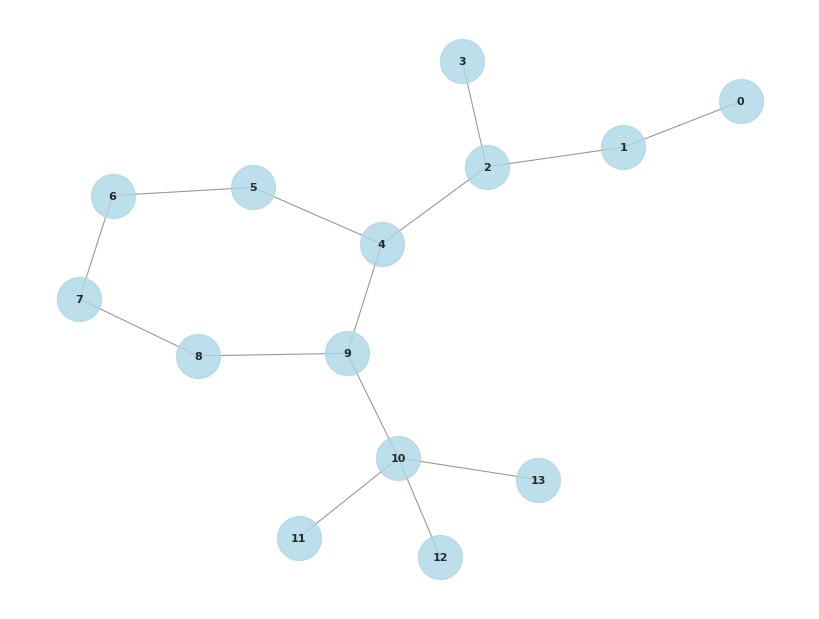

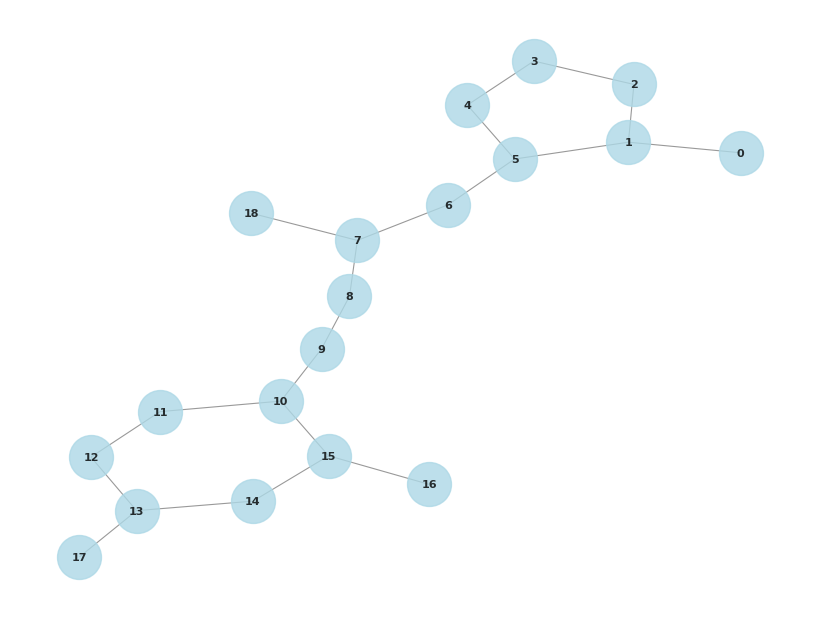

In [5]:
PlotGraph(G1)
PlotGraph(G2)

### 1) Only count the number of vertices for each possible label value

In [6]:
def Emb_Nodes(G):
    labels = [data['node_label'] for _, data in G.nodes(data=True)]
    unique_labels = sorted(set(labels))

    label_to_index = {label: i for i, label in enumerate(unique_labels)}
    emb = np.zeros(len(unique_labels))

    for label in labels:
        emb[label_to_index[label]] += 1

    return emb

In [7]:
print(f"Embedding G1 = {Emb_Nodes(G1)}")
print(f"\nEmbedding G2 = {Emb_Nodes(G2)}")

Embedding G1 = [8. 1. 4. 1.]

Embedding G2 = [13.  2.  2.  2.]


### 2) Add the number of edges with two specific labels at end vertices

In [8]:
def Emb_Nodes(G):
    # count node
    node_labels = [data['node_label'] for _, data in G.nodes(data=True)]
    unique_labels = sorted(set(node_labels))

    node_counts = Counter(node_labels)
    node_embedding = np.array([node_counts[label] for label in unique_labels])

    # edge count
    edge_label_pairs = []

    for u, v in G.edges():
        lu = G.nodes[u]['node_label']
        lv = G.nodes[v]['node_label']
        pair = tuple(sorted((lu, lv)))
        edge_label_pairs.append(pair)

    edge_counts = Counter(edge_label_pairs)

    # ordering
    label_pairs = list(combinations_with_replacement(unique_labels, 2))
    edge_embedding = np.array([edge_counts[pair] for pair in label_pairs])

    return np.concatenate([node_embedding, edge_embedding])


In [9]:
print(f"Embedding G1 = {Emb_Nodes(G1)}")
print(f"\nEmbedding G2 = {Emb_Nodes(G2)}")

Embedding G1 = [8 1 4 1 7 0 3 1 0 0 1 0 2 0]

Embedding G2 = [13  2  2  2 10  2  5  3  0  0  0  0  0  0]


[node_A, node_B, node_C,
 edges_AA, edges_AB, edges_AC, edges_BB, edges_BC, edges_CC]

### 3) Graph probing (add the count for edge structures)

In [10]:
def Emb_Graph_Probing(G):
    # node count
    node_labels = [data['node_label'] for _, data in G.nodes(data=True)]
    unique_labels = sorted(set(node_labels))

    node_counts = Counter(node_labels)
    node_emb = np.array([node_counts[l] for l in unique_labels])

    # edge count
    edge_label_pairs = []
    for u, v in G.edges():
        pair = tuple(sorted((G.nodes[u]['node_label'], G.nodes[v]['node_label'])))
        edge_label_pairs.append(pair)

    edge_pair_counts = Counter(edge_label_pairs)
    label_pairs = list(combinations_with_replacement(unique_labels, 2))
    edge_label_emb = np.array([edge_pair_counts[p] for p in label_pairs])

    # probing
    num_edges = G.number_of_edges()

    # lenth 2
    wedges = sum(len(list(nx.neighbors(G, v))) * (len(list(nx.neighbors(G, v))) - 1) // 2 for v in G.nodes())

    # lenth 3
    triangles = sum(nx.triangles(G).values()) // 3

    structure_emb = np.array([num_edges, wedges, triangles])

    return np.concatenate([node_emb, edge_label_emb, structure_emb])


In [11]:
print(f"Embedding G1 = {Emb_Graph_Probing(G1)}")
print(f"\nEmbedding G2 = {Emb_Graph_Probing(G2)}")

Embedding G1 = [ 8  1  4  1  7  0  3  1  0  0  1  0  2  0 14 20  0]

Embedding G2 = [13  2  2  2 10  2  5  3  0  0  0  0  0  0 20 27  0]


### 4) Count the number of occurrences of graph patterns. The graph pattern dictionnary is given as a parameter

In [12]:
def Emb_Graph_Patterns(G, pattern_dict):
    embedding = []

    for name, pattern in pattern_dict.items():
        GM = isomorphism.GraphMatcher(G, pattern)

        count = 0
        for _ in GM.subgraph_isomorphisms_iter():
            count += 1

        embedding.append(count)

    return np.array(embedding)


In [13]:
# Single Edge
edge = nx.Graph()
edge.add_edge(1, 2)

# 3 nodes line
path_2 = nx.Graph()
path_2.add_edges_from([
    (1, 2),
    (2, 3)
])

# 4 nodes line
path_3 = nx.Graph()
path_3.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 4)
])

# Triangle
triangle = nx.Graph()
triangle.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 1)
])

# Square
square = nx.Graph()
square.add_edges_from([
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 1)
])

# center with 3 leaves
star = nx.Graph()
star.add_edges_from([
    (1, 2),
    (1, 3),
    (1, 4)
])

# T-shape
t_shape = nx.Graph()
t_shape.add_edges_from([
    (1, 2),
    (2, 3),
    (2, 4)
])

# dictionary
pattern_dict = {
    "edge": edge,
    "path2": path_2,
    "path3": path_3,
    "triangle": triangle,
    "square": square,
    "star": star,
    "t_shape": t_shape
}


In [14]:
print(f"Embedding G1 = {Emb_Graph_Patterns(G1, pattern_dict)}")
print(f"\nEmbedding G2 = {Emb_Graph_Patterns(G2, pattern_dict)}")

Embedding G1 = [28 40 46  0  0 42 42]

Embedding G2 = [40 54 64  0  0 36 36]


### 5) Count the number of occurences of all non-isomorphic pattern whose number of edges is lower than $n$. $n$ is given as a parameter (slide 35)

In [15]:
def Emb_All_NonIsomorphic(G, n):
    patterns = []
    counts = []

    max_nodes = n + 1

    for k in range(2, max_nodes + 1):
        for H in nx.graph_atlas_g():
            if H.number_of_nodes() != k:
                continue

            if H.number_of_edges() >= n or H.number_of_edges() == 0:
                continue

            # Check if isomorphic
            is_new = True
            for P in patterns:
                if nx.is_isomorphic(H, P):
                    is_new = False
                    break

            if is_new:
                patterns.append(H)

    # Count each pattern in G
    for pattern in patterns:
        GM = isomorphism.GraphMatcher(G, pattern)
        count = sum(1 for _ in GM.subgraph_isomorphisms_iter())
        counts.append(count)

    return np.array(counts), patterns

In [16]:
n = 3

embedding, patterns = Emb_All_NonIsomorphic(G1, n)
print(f"Embedding G1 = {embedding}")

embedding, patterns = Emb_All_NonIsomorphic(G2, n)
print(f"Embedding G2 = {embedding}")



Embedding G1 = [  28  256   40 1728  306  384]
Embedding G2 = [  40  572   54 6576  700 1048]


### 6) Count the number of cycles of length 3, 4 and 5

In [17]:
def Emb_Cycle_Lengths(G):
    cycles = nx.simple_cycles(G.to_directed())

    c3 = c4 = c5 = c6 = 0

    for cycle in cycles:
        length = len(cycle)
        if length == 3:
            c3 += 1
        elif length == 4:
            c4 += 1
        elif length == 5:
            c5 += 1
        elif length == 6:
            c6 += 1

    # Each undirected cycle appears twice
    return np.array([c3 // 2, c4 // 2, c5 // 2, c6 // 2])


In [18]:
print(f"Embedding G1 = {Emb_Cycle_Lengths(G1)}")
print(f"\nEmbedding G2 = {Emb_Cycle_Lengths(G2)}")

Embedding G1 = [0 0 0 1]

Embedding G2 = [0 0 1 1]


[ number_of_3_cycles , number_of_4_cycles , number_of_5_cycles , number_of_6_cycles]


### 7) Apply a classification algorithm (knn for example) based on these embedding

In [19]:
def build_embedding(G, pattern_dict, n_iso):
    e1 = Emb_Nodes(G)
    e2 = Emb_Graph_Probing(G)
    e3 = Emb_Graph_Patterns(G, pattern_dict)
    e4, _ = Emb_All_NonIsomorphic(G, n_iso)
    e5 = Emb_Cycle_Lengths(G)

    return np.concatenate([e1, e2, e3, e4, e5])


In [37]:
def pipeline(dataframe):
  #####
  graphs = []
  labels = []

  for _, row in dataframe.iterrows():
      G = smiles_to_networkx(row['smiles'])
      graphs.append(G)
      labels.append(row['label'])

  X = []
  y = np.array(labels)

  total = len(graphs)

  raw_embeddings = []

  # compute embeddings
  for i, G in enumerate(graphs, start=1):
      emb = build_embedding(G, pattern_dict, n_iso=3)
      raw_embeddings.append(emb)

      if i % max(1, total // 20) == 0 or i == total:
          percent = (i / total) * 100
          print(f"Progress: {percent:.1f}% ({i}/{total})")

  # find max emb size
  max_len = max(len(e) for e in raw_embeddings)
  print("Max embedding size:", max_len)

  # pad emb
  X = np.zeros((len(raw_embeddings), max_len))

  for i, emb in enumerate(raw_embeddings):
      X[i, :len(emb)] = emb

  print("Final feature matrix shape:", X.shape)

  #####
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, random_state=42
  )

  knn = KNeighborsClassifier(n_neighbors=5)
  knn.fit(X_train, y_train)

  y_pred = knn.predict(X_test)

  print("Accuracy:", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))


Dataset AC Smiles



In [23]:
df = pd.read_csv("AC_smiles.csv")
print(df.head())

         mol_id                                             smiles  label
0  ZINC00042604            CCOc1c(c(cc(n1)c1ccccc1)c1ccc(cc1)C)C#N      0
1  ZINC00048354     c1cc(oc1)/C=C/C=C/1\CCC/C(=C/C=C/c2ccco2)/C1=O      0
2  ZINC00056300                  CC1(Cc2c(c(o[nH+]2)N)C(N1O)(C)C)C      0
3  ZINC00056588                          COC(=O)c1ccccc1S(=O)(=O)N      0
4  ZINC00064303  c1cc(ccc1/C=N/N1C(=O)[C@@H]2[C@H]3C=C[C@@H]([C...      0


In [24]:
pipeline(df)

Progress: 5.0% (216/4326)
Progress: 10.0% (432/4326)
Progress: 15.0% (648/4326)
Progress: 20.0% (864/4326)
Progress: 25.0% (1080/4326)
Progress: 30.0% (1296/4326)
Progress: 35.0% (1512/4326)
Progress: 39.9% (1728/4326)
Progress: 44.9% (1944/4326)
Progress: 49.9% (2160/4326)
Progress: 54.9% (2376/4326)
Progress: 59.9% (2592/4326)
Progress: 64.9% (2808/4326)
Progress: 69.9% (3024/4326)
Progress: 74.9% (3240/4326)
Progress: 79.9% (3456/4326)
Progress: 84.9% (3672/4326)
Progress: 89.9% (3888/4326)
Progress: 94.9% (4104/4326)
Progress: 99.9% (4320/4326)
Progress: 100.0% (4326/4326)
Max embedding size: 90
Final feature matrix shape: (4326, 90)
Accuracy: 0.7541589648798521
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       811
           1       0.51      0.39      0.44       271

    accuracy                           0.75      1082
   macro avg       0.66      0.63      0.64      1082
weighted avg       0.74      0.75      0.74      1082

Dataset Benzene Smiles

In [38]:
df2 = pd.read_csv("benzene_smiles.csv")
df2 = df2.drop("mol", axis='columns')
print(df2.head())

         mol_id                                          smiles  label
0  ZINC72292955     c1cc(ncc1NC(=O)C1CCCCC1)n1cc(cn1)S(=O)(=O)N    0.0
1  ZINC66294494  C[C@H](C(=O)Nc1ccccc1F)[S@@](=O)C/C=C/c1ccccc1    1.0
2  ZINC07601739                          c1ccc(cc1)CNn1c(nnn1)N    1.0
3  ZINC04127898          CC(=O)N(C)c1ccc(c2c1cccc2)[N+](=O)[O-]    1.0
4  ZINC33699343         CC(=O)/C(=C/NCCN1CCOCC1)/C(=O)Nc1ccccc1    1.0


In [39]:
pipeline(df2)

Progress: 5.0% (600/12000)
Progress: 10.0% (1200/12000)
Progress: 15.0% (1800/12000)
Progress: 20.0% (2400/12000)
Progress: 25.0% (3000/12000)
Progress: 30.0% (3600/12000)
Progress: 35.0% (4200/12000)
Progress: 40.0% (4800/12000)
Progress: 45.0% (5400/12000)
Progress: 50.0% (6000/12000)
Progress: 55.0% (6600/12000)
Progress: 60.0% (7200/12000)
Progress: 65.0% (7800/12000)
Progress: 70.0% (8400/12000)
Progress: 75.0% (9000/12000)
Progress: 80.0% (9600/12000)
Progress: 85.0% (10200/12000)
Progress: 90.0% (10800/12000)
Progress: 95.0% (11400/12000)
Progress: 100.0% (12000/12000)
Max embedding size: 90
Final feature matrix shape: (12000, 90)
Accuracy: 0.6803333333333333
              precision    recall  f1-score   support

         0.0       0.69      0.64      0.67      1492
         1.0       0.67      0.72      0.69      1508

    accuracy                           0.68      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.68      0.68      0.68      3000